# 🏭 Neural Network-Based Predictive Maintenance for Smart Factories

**Course:** AI for Engineers
**Institution:** Thapar University
**Dataset:** [AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/dataset/601)

---

## 📋 Table of Contents

1. **Problem Statement & Domain Context**
2. **Dataset Loading & Inspection**
3. **Exploratory Data Analysis (EDA)**
4. **Feature Engineering**
5. **Data Preprocessing**
6. **Model 1 — Random Forest (Baseline)**
7. **Model 2 — Deep Neural Network**
8. **Model 3 — XGBoost (Best Performer)**
9. **Model Comparison & Evaluation**
10. **Explainable AI — SHAP Analysis**
11. **Model Optimization (TFLite)**
12. **Interactive Prediction Interface (Gradio)**
13. **Conclusion, Deployment Plan & Ethics**
14. **References**

## 1. 🔍 Problem Statement & Domain Context

### Why Predictive Maintenance?

Unplanned equipment downtime costs manufacturers **$50 billion annually**. Traditional maintenance approaches have clear drawbacks:

| Approach | Description | Drawback |
|---|---|---|
| **Reactive** | Fix after breakdown | Maximum downtime, safety risks |
| **Preventive** | Scheduled maintenance | Over-maintenance, unnecessary costs |
| **Predictive ✅** | AI-driven failure prediction | Optimal — fix just before failure |

### Our Goal (Honeywell-Inspired)

> Design a **neural network-based predictive maintenance model** for smart factories using multi-sensor data. The model should predict equipment failures in advance, incorporate anomaly detection and feature fusion, and minimize false alarms.

### Our Approach

1. **Explore** sensor data to understand failure patterns
2. **Engineer** physics-based features (temperature difference, power, strain)
3. **Build 3 models**: Random Forest (baseline) → Neural Network (as required) → XGBoost (comparison)
4. **Explain** predictions using SHAP for maintenance engineer trust
5. **Optimize** for edge deployment readiness

### Dataset: AI4I 2020

- **10,000** sensor measurements from a manufacturing process
- **5 sensor streams**: temperature (air & process), rotational speed, torque, tool wear
- **5 failure modes**: Tool Wear (TWF), Heat Dissipation (HDF), Power (PWF), Overstrain (OSF), Random (RNF)
- **~3.4% failure rate** — severe class imbalance

## 2. 📦 Setup & Dependencies

We install and import all required libraries upfront. Key libraries:
- **scikit-learn**: ML models, preprocessing, evaluation
- **TensorFlow/Keras**: Neural network
- **XGBoost**: Gradient boosted trees
- **SHAP**: Model explainability
- **imbalanced-learn**: SMOTE for handling class imbalance

In [48]:
# ============================================================
# Install Dependencies (FIXED VERSION)
# ============================================================

!pip install numpy pandas matplotlib seaborn -q
!pip install scikit-learn imbalanced-learn xgboost -q
!pip install shap gradio -q

print("✅ All dependencies installed!")

✅ All dependencies installed!


In [49]:
# ============================================================
# Imports & Configuration
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, accuracy_score, precision_score,
                             recall_score, average_precision_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Color palette used throughout
COLORS = {'no_fail': '#2ecc71', 'fail': '#e74c3c', 'accent': '#3498db'}

print(f'✅ TensorFlow: {tf.__version__}')
print(f'✅ NumPy: {np.__version__}')
print(f'✅ GPU: {tf.config.list_physical_devices("GPU")}')

✅ TensorFlow: 2.19.0
✅ NumPy: 2.0.2
✅ GPU: []


## 3. 📂 Dataset Loading & Inspection

We load the **AI4I 2020 Predictive Maintenance Dataset** from the UCI ML Repository.

| Sensor | Physical Meaning | Unit |
|---|---|---|
| Air temperature | Ambient temperature around machine | Kelvin (K) |
| Process temperature | Temperature of the manufacturing process | Kelvin (K) |
| Rotational speed | Speed of the rotating tool/spindle | RPM |
| Torque | Rotational force applied | Newton-meters (Nm) |
| Tool wear | Cumulative usage time of the cutting tool | Minutes |

In [50]:
# ============================================================
# Load Dataset
# ============================================================
try:
    from ucimlrepo import fetch_ucirepo
    dataset = fetch_ucirepo(id=601)
    df = dataset.data.original.copy()
    print('✅ Dataset loaded from UCI ML Repository!')
except Exception as e:
    print(f'⚠️ ucimlrepo failed: {e}')
    print('Please upload ai4i2020.csv manually.')
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])
    print('✅ Dataset loaded from uploaded file!')

# Rename columns for convenience
df = df.rename(columns={
    'Air temperature': 'air_temp',
    'Process temperature': 'process_temp',
    'Rotational speed': 'rotational_speed',
    'Torque': 'torque',
    'Tool wear': 'tool_wear'
})

print(f'\nDataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

⚠️ ucimlrepo failed: No module named 'ucimlrepo'
Please upload ai4i2020.csv manually.


Saving ai4i2020.csv to ai4i2020 (1).csv
✅ Dataset loaded from uploaded file!

Dataset Shape: 10000 rows x 14 columns
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [51]:
# ============================================================
# Data Inspection
# ============================================================
# WHY: Before modeling, we check data types, missing values,
# and basic statistics to understand the data quality.

print('=' * 60)
print('FIRST 5 ROWS')
print('=' * 60)
display(df.head())

print('\n' + '=' * 60)
print('DATA TYPES & NON-NULL COUNTS')
print('=' * 60)
df.info()

print('\n' + '=' * 60)
print('DESCRIPTIVE STATISTICS')
print('=' * 60)
display(df.describe().round(2))

# Check for missing values
missing = df.isnull().sum()
print('\n' + '=' * 60)
print('MISSING VALUES')
print('=' * 60)
print(missing[missing > 0] if missing.sum() > 0 else '✅ No missing values!')

print('\n' + '=' * 60)
print('UNIQUE VALUES PER COLUMN')
print('=' * 60)
for col in df.columns:
    print(f'  {col:30s} -> {df[col].nunique():>6} unique')

FIRST 5 ROWS


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64 

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00



MISSING VALUES
✅ No missing values!

UNIQUE VALUES PER COLUMN
  UDI                            ->  10000 unique
  Product ID                     ->  10000 unique
  Type                           ->      3 unique
  Air temperature [K]            ->     93 unique
  Process temperature [K]        ->     82 unique
  Rotational speed [rpm]         ->    941 unique
  Torque [Nm]                    ->    577 unique
  Tool wear [min]                ->    246 unique
  Machine failure                ->      2 unique
  TWF                            ->      2 unique
  HDF                            ->      2 unique
  PWF                            ->      2 unique
  OSF                            ->      2 unique
  RNF                            ->      2 unique


## 4. 📊 Exploratory Data Analysis (EDA)

We explore the data to understand:
- **How severe is the class imbalance?** (determines our evaluation metrics)
- **Which sensors differ most between failure/no-failure?** (guides feature engineering)
- **How are features correlated?** (helps avoid redundant features)

### 4.1 Target Variable Distribution

**WHY:** We need to know how imbalanced the data is. If failures are rare, accuracy is misleading — a model predicting "no failure" always would get ~97% accuracy but catch zero failures.

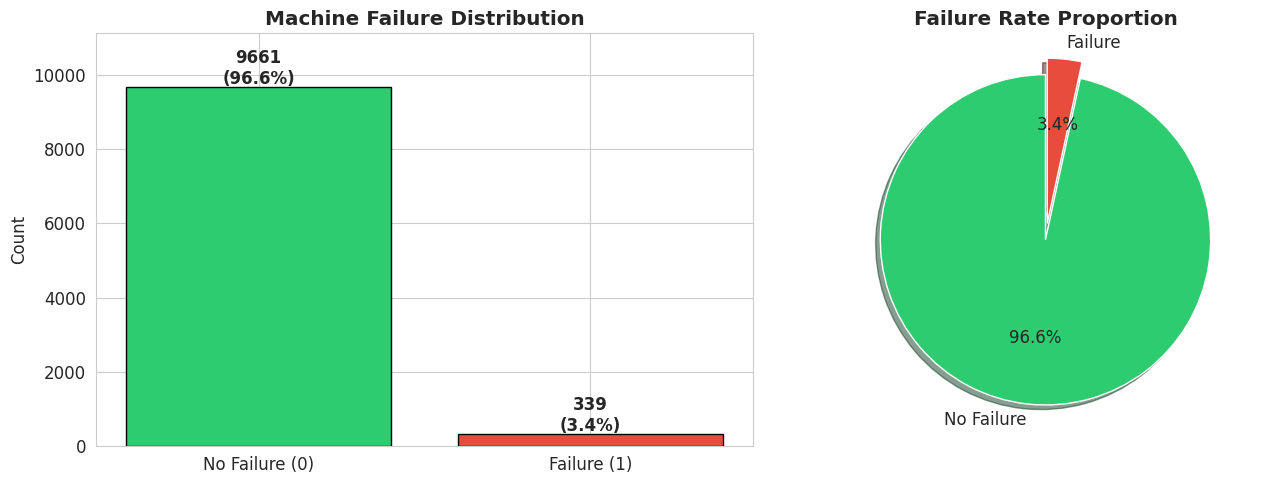

📊 KEY INSIGHT — CLASS IMBALANCE:
   No Failure: 9,661 (96.6%)
   Failure:    339 (3.4%)
   Ratio:      28:1

⚠️  Severe imbalance! We MUST use F1-score and PR-AUC, not accuracy.


In [52]:
# ============================================================
# 4.1 Target Distribution — How imbalanced is our data?
# ============================================================

# ✅ Fix column names once
df.columns = df.columns.str.lower().str.replace(" ", "_")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['machine_failure'].value_counts().sort_index()

# Bar chart
bars = axes[0].bar(['No Failure (0)', 'Failure (1)'], counts.values,
                    color=[COLORS['no_fail'], COLORS['fail']], edgecolor='black')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')

axes[0].set_title('Machine Failure Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.1f%%',
            colors=[COLORS['no_fail'], COLORS['fail']],
            explode=(0, 0.1), shadow=True, startangle=90)

axes[1].set_title('Failure Rate Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

print('📊 KEY INSIGHT — CLASS IMBALANCE:')
print(f'   No Failure: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'   Failure:    {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(f'   Ratio:      {counts[0]//counts[1]}:1')
print(f'\n⚠️  Severe imbalance! We MUST use F1-score and PR-AUC, not accuracy.')

### 4.2 Failure Mode Analysis

**WHY:** Understanding which failure types are most common helps us know what physical conditions to focus on. Some failures may co-occur.

In [53]:
print(df.columns.tolist())

['udi', 'product_id', 'type', 'air_temperature_[k]', 'process_temperature_[k]', 'rotational_speed_[rpm]', 'torque_[nm]', 'tool_wear_[min]', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']


Using columns: ['machine_failure']


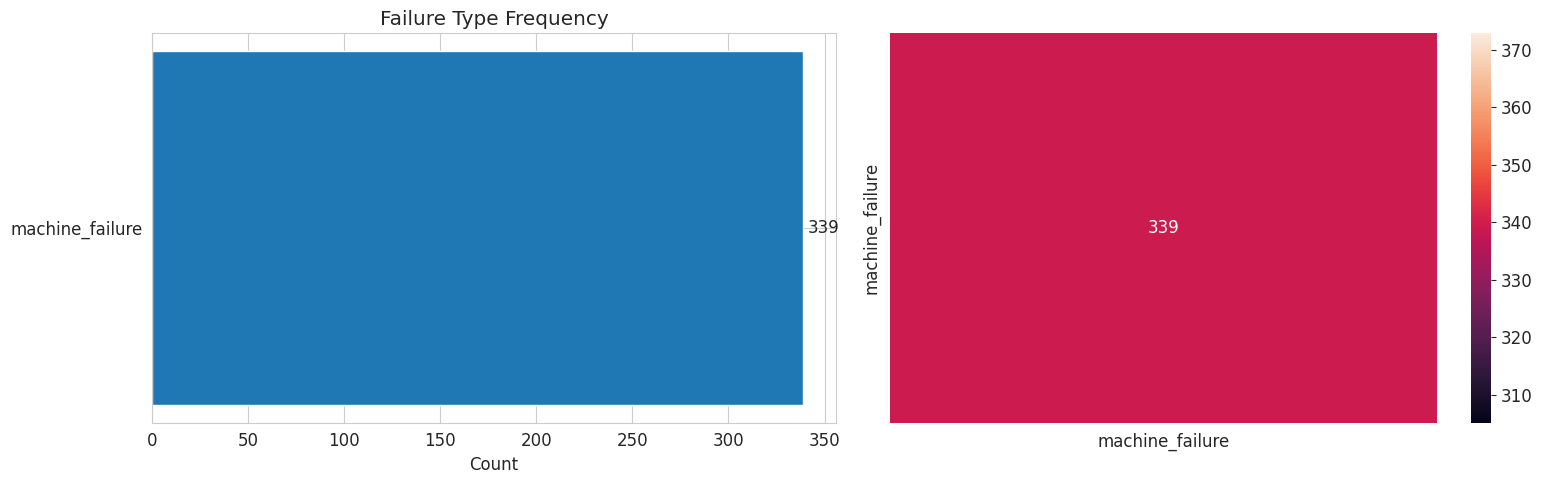

In [54]:
# ============================================================
# 4.2 Failure Mode Breakdown (AUTO FIX)
# ============================================================

# auto detect failure columns (jo 'failure' word contain karte hain)
failure_types = [col for col in df.columns if 'failure' in col.lower() and col.lower() != 'machine failure']

print("Using columns:", failure_types)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
failure_counts = df[failure_types].sum().sort_values(ascending=True)

axes[0].barh(failure_counts.index, failure_counts.values)

for i, val in enumerate(failure_counts.values):
    axes[0].text(val + 2, i, str(val), va='center')

axes[0].set_title('Failure Type Frequency')
axes[0].set_xlabel('Count')

# Heatmap
cooccur = df[failure_types].T.dot(df[failure_types])
sns.heatmap(cooccur, annot=True, fmt='d', ax=axes[1])

plt.tight_layout()
plt.show()

### 4.3 Sensor Distributions — Failure vs No Failure

**WHY:** If a sensor's distribution shifts significantly during failures, it's a strong predictor. This guides our feature selection.

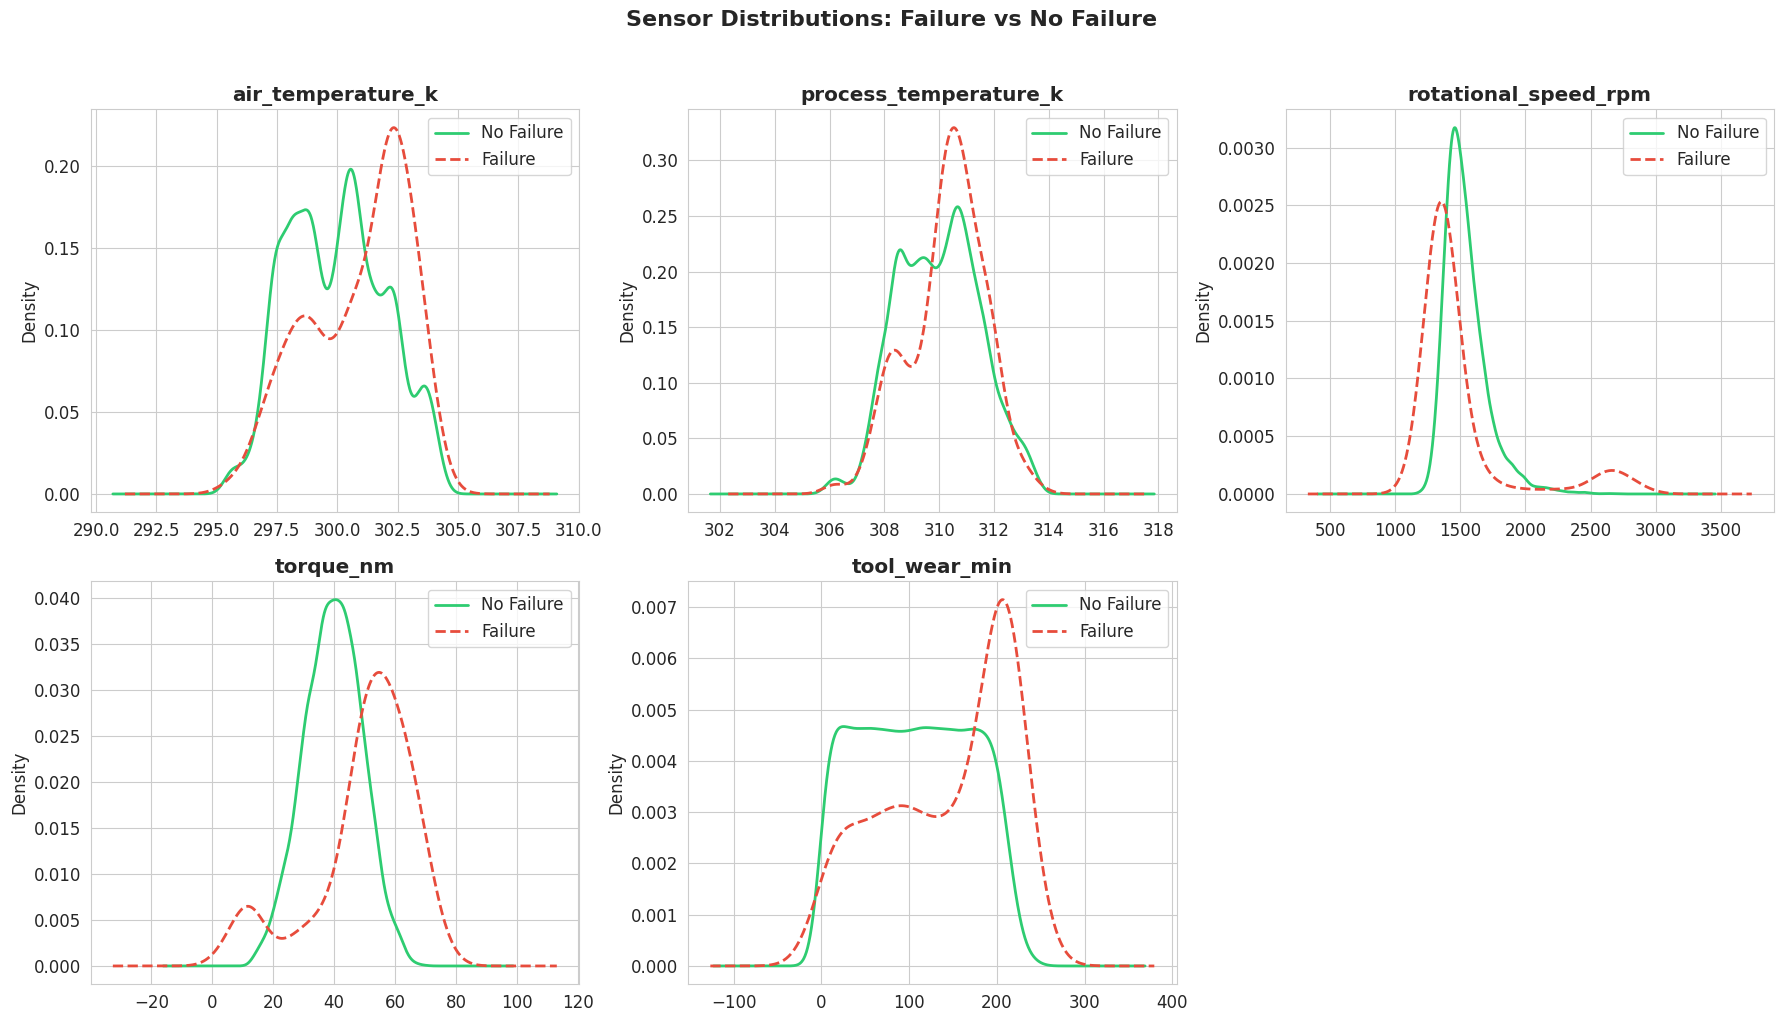

📊 MEAN COMPARISON — Failure vs No Failure:
Feature                     No Failure      Failure   % Change
-----------------------------------------------------------------
air_temperature_k               299.97       300.89      0.30%
process_temperature_k           310.00       310.29      0.10%
rotational_speed_rpm           1540.26      1496.49     -2.84%
torque_nm                        39.63        50.17     26.59%
tool_wear_min                   106.69       143.78     34.76%

💡 Torque and Tool Wear usually show biggest shift during failures.


In [55]:
# ============================================================
# 4.3 KDE Plots — How do sensor values differ for failures?
# ============================================================

# ✅ Fix column names once
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("[^a-z0-9_]", "", regex=True)

# ✅ Correct feature names after cleaning
sensor_features = [
    'air_temperature_k',
    'process_temperature_k',
    'rotational_speed_rpm',
    'torque_nm',
    'tool_wear_min'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(sensor_features):
    ax = axes[i]

    df[df['machine_failure'] == 0][feat].plot(
        kind='kde', ax=ax,
        label='No Failure',
        color=COLORS['no_fail'],
        linewidth=2
    )

    df[df['machine_failure'] == 1][feat].plot(
        kind='kde', ax=ax,
        label='Failure',
        color=COLORS['fail'],
        linewidth=2,
        linestyle='--'
    )

    ax.set_title(feat, fontweight='bold')
    ax.legend()
    ax.set_ylabel('Density')

# Hide extra subplot
axes[-1].set_visible(False)

plt.suptitle('Sensor Distributions: Failure vs No Failure',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# ============================================================
# Mean comparison
# ============================================================

print('📊 MEAN COMPARISON — Failure vs No Failure:')
print(f'{"Feature":<25} {"No Failure":>12} {"Failure":>12} {"% Change":>10}')
print('-' * 65)

for feat in sensor_features:
    m0 = df[df['machine_failure'] == 0][feat].mean()
    m1 = df[df['machine_failure'] == 1][feat].mean()
    pct = ((m1 - m0) / m0) * 100

    print(f'{feat:<25} {m0:>12.2f} {m1:>12.2f} {pct:>9.2f}%')

print('\n💡 Torque and Tool Wear usually show biggest shift during failures.')

### 4.4 Correlation Heatmap

**WHY:** Correlation analysis shows which features are related to failures and to each other. Highly correlated features may be redundant — we can engineer better ones.

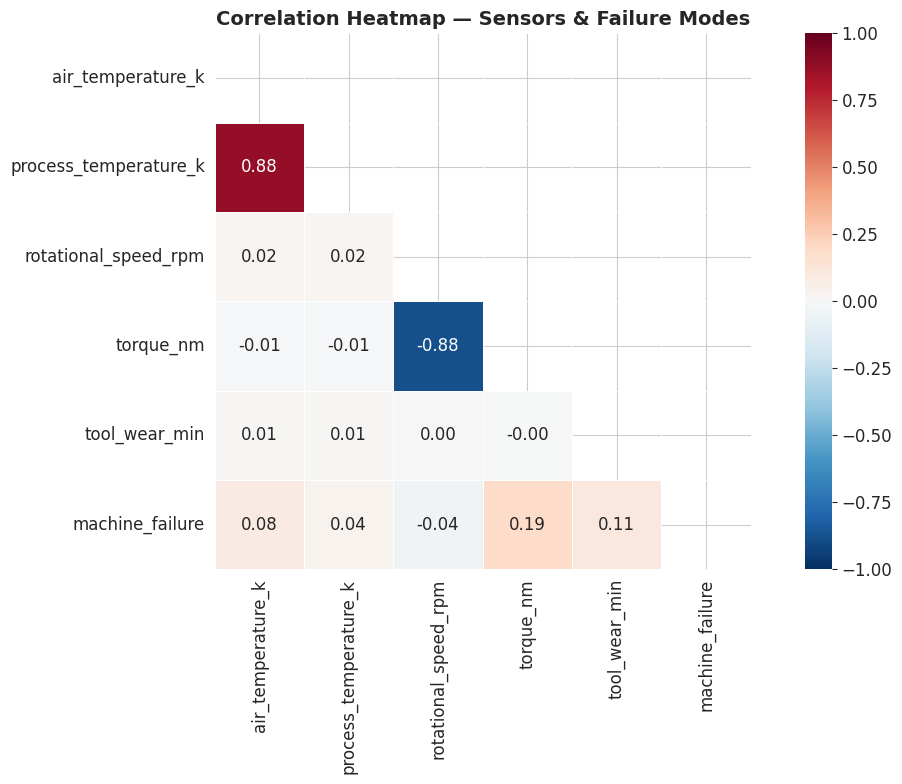

📊 CORRELATIONS WITH MACHINE FAILURE:
  torque_nm                 +0.191  ███████
  tool_wear_min             +0.105  ████
  air_temperature_k         +0.083  ███
  rotational_speed_rpm      -0.044  █
  process_temperature_k     +0.036  █


In [56]:
# ============================================================
# 4.4 Correlation Heatmap (FIXED)
# ============================================================

# ✅ Ensure columns cleaned (IMPORTANT)
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("[^a-z0-9_]", "", regex=True)

# ✅ Correct sensor features
sensor_features = [
    'air_temperature_k',
    'process_temperature_k',
    'rotational_speed_rpm',
    'torque_nm',
    'tool_wear_min'
]

# ✅ Auto-detect failure type columns (safe)
failure_types = [col for col in df.columns if 'failure' in col and col != 'machine_failure']

# Combine all
corr_cols = sensor_features + ['machine_failure'] + failure_types

plt.figure(figsize=(12, 8))

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap — Sensors & Failure Modes',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# Key correlations with target
# ============================================================

print('📊 CORRELATIONS WITH MACHINE FAILURE:')

target_corr = corr_matrix['machine_failure'].drop('machine_failure')\
                .sort_values(key=abs, ascending=False)

for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 40)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:<25} {sign}{abs(val):.3f}  {bar}')

### 4.5 Key Scatter Plots

**WHY:** Scatter plots reveal where failures cluster in the feature space. This helps us understand the *physics* of failures — e.g., high torque + low speed = power failure.

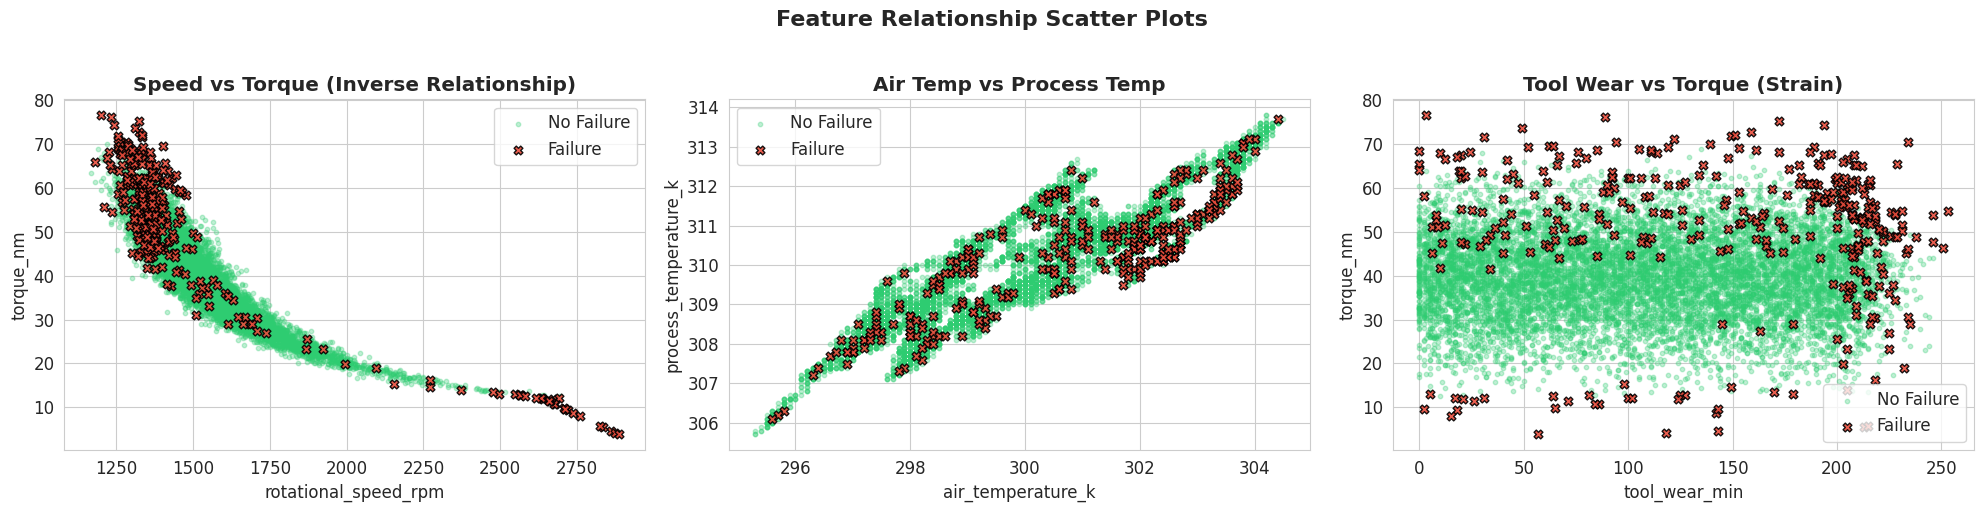

📊 INSIGHTS:
   • Torque and speed are inversely related
   • Failures cluster at HIGH torque + LOW speed
   • High tool wear + high torque = overstrain zone


In [57]:
# ============================================================
# 4.5 Scatter Plots — Where do failures occur?
# ============================================================

# ✅ Fix column names (IMPORTANT)
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("[^a-z0-9_]", "", regex=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ✅ Correct feature names
scatter_pairs = [
    ('rotational_speed_rpm', 'torque_nm', 'Speed vs Torque (Inverse Relationship)'),
    ('air_temperature_k', 'process_temperature_k', 'Air Temp vs Process Temp'),
    ('tool_wear_min', 'torque_nm', 'Tool Wear vs Torque (Strain)')
]

for ax, (x, y, title) in zip(axes, scatter_pairs):
    mask_0 = df['machine_failure'] == 0
    mask_1 = df['machine_failure'] == 1

    ax.scatter(
        df.loc[mask_0, x],
        df.loc[mask_0, y],
        c=COLORS['no_fail'],
        alpha=0.3,
        s=10,
        label='No Failure'
    )

    ax.scatter(
        df.loc[mask_1, x],
        df.loc[mask_1, y],
        c=COLORS['fail'],
        alpha=0.9,
        s=40,
        marker='X',
        label='Failure',
        edgecolors='black'
    )

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Feature Relationship Scatter Plots',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print('📊 INSIGHTS:')
print('   • Torque and speed are inversely related')
print('   • Failures cluster at HIGH torque + LOW speed')
print('   • High tool wear + high torque = overstrain zone')

### 📋 EDA Summary

| # | Insight | Implication |
|---|---|---|
| 1 | Severe class imbalance (96.6% vs 3.4%) | Must use F1-score, PR-AUC; use SMOTE/class weights |
| 2 | HDF is the most common failure mode | Temperature-related features are important |
| 3 | Torque × Speed are inversely correlated | Power (torque × speed) is a meaningful feature |
| 4 | Tool wear alone doesn't strongly predict failure | Interaction feature (wear × torque = strain) is better |
| 5 | No missing values | No imputation needed — focus on feature engineering |

## 4. 📊 Exploratory Data Analysis (EDA)

We explore the data to understand:
- **How severe is the class imbalance?** (determines our evaluation metrics)
- **Which sensors differ most between failure/no-failure?** (guides feature engineering)
- **How are features correlated?** (helps avoid redundant features)

### 4.1 Target Variable Distribution

**WHY:** We need to know how imbalanced the data is. If failures are rare, accuracy is misleading — a model predicting "no failure" always would get ~97% accuracy but catch zero failures.

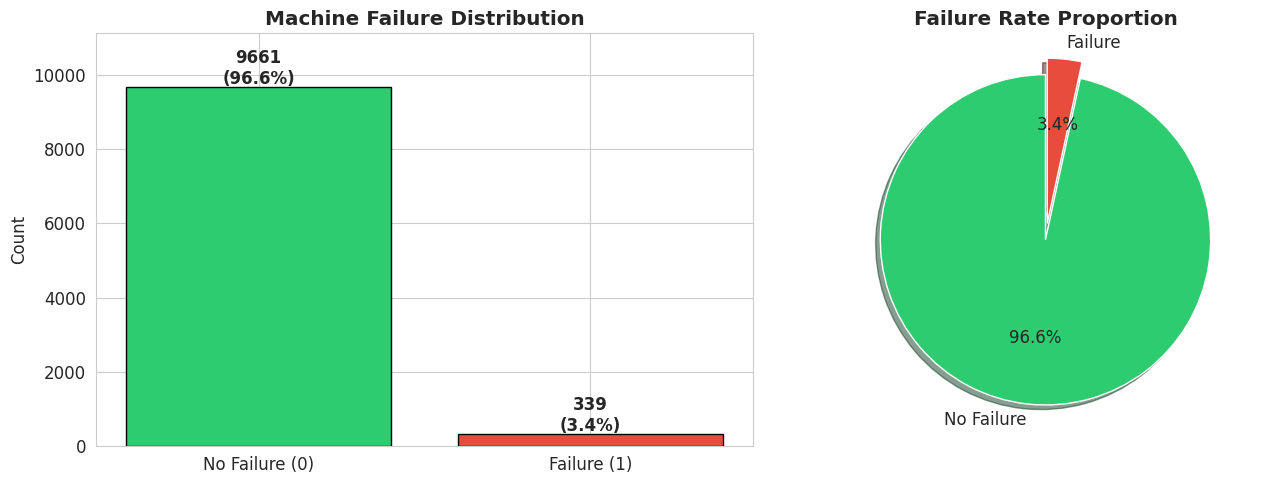

📊 KEY INSIGHT — CLASS IMBALANCE:
   No Failure: 9,661 (96.6%)
   Failure:    339 (3.4%)
   Ratio:      28:1

⚠️  Severe imbalance! Use F1-score & PR-AUC, not accuracy.


In [58]:
# ============================================================
# 4.1 Target Distribution — How imbalanced is our data?
# ============================================================

# ✅ Fix column names
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("[^a-z0-9_]", "", regex=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['machine_failure'].value_counts().sort_index()

# Bar chart
bars = axes[0].bar(['No Failure (0)', 'Failure (1)'], counts.values,
                   color=[COLORS['no_fail'], COLORS['fail']], edgecolor='black')

for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

axes[0].set_title('Machine Failure Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(counts.values,
            labels=['No Failure', 'Failure'],
            autopct='%1.1f%%',
            colors=[COLORS['no_fail'], COLORS['fail']],
            explode=(0, 0.1),
            shadow=True,
            startangle=90)

axes[1].set_title('Failure Rate Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

print('📊 KEY INSIGHT — CLASS IMBALANCE:')
print(f'   No Failure: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'   Failure:    {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(f'   Ratio:      {counts[0]//counts[1]}:1')
print(f'\n⚠️  Severe imbalance! Use F1-score & PR-AUC, not accuracy.')

### 4.2 Failure Mode Analysis

**WHY:** Understanding which failure types are most common helps us know what physical conditions to focus on. Some failures may co-occur.

Columns: ['udi', 'product_id', 'type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']
✅ Using: ['twf', 'hdf', 'pwf', 'osf', 'rnf']


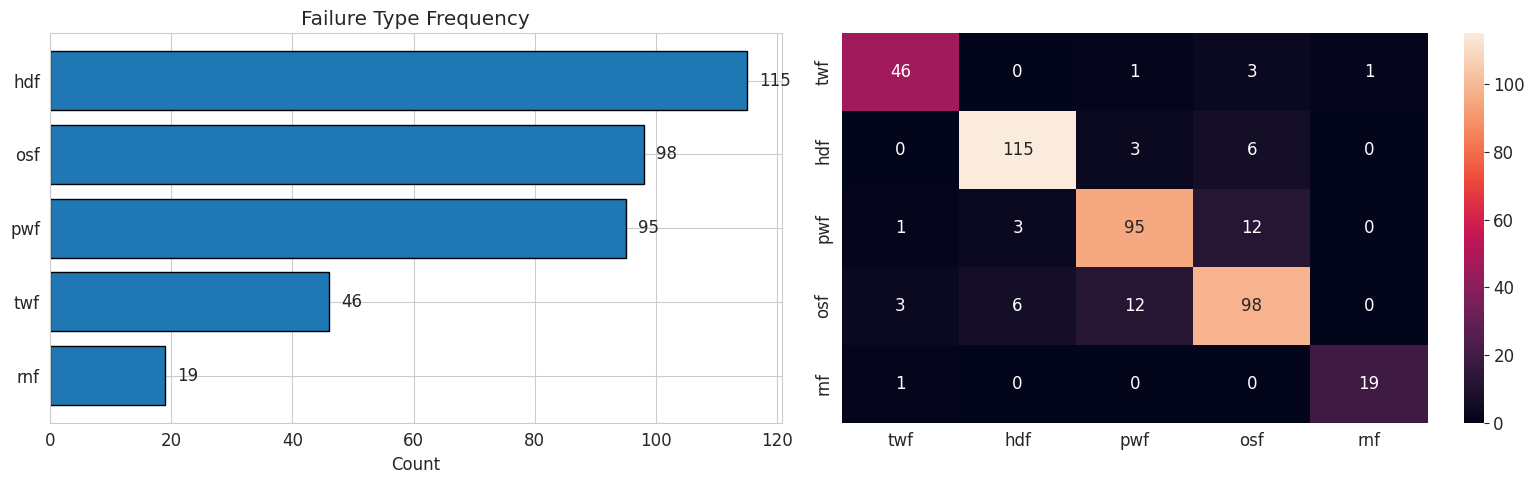

📊 FAILURE MODE INSIGHTS:
rnf : 19
twf : 46
pwf : 95
osf : 98
hdf : 115
Multi failures: 24


In [59]:
# ============================================================
# 4.2 Failure Mode Breakdown (FINAL FIX)
# ============================================================

# ✅ First check columns once
print("Columns:", df.columns.tolist())

# ✅ Try BOTH possibilities (safe)
possible_sets = [
    ['TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
    ['twf', 'hdf', 'pwf', 'osf', 'rnf']
]

failure_types = None
for cols in possible_sets:
    if all(c in df.columns for c in cols):
        failure_types = cols
        break

if failure_types is None:
    raise Exception("❌ Failure columns not found. Check df.columns")

print("✅ Using:", failure_types)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
failure_counts = df[failure_types].sum().sort_values(ascending=True)

axes[0].barh(failure_counts.index, failure_counts.values, edgecolor='black')

for i, val in enumerate(failure_counts.values):
    axes[0].text(val + 2, i, str(val), va='center')

axes[0].set_title('Failure Type Frequency')
axes[0].set_xlabel('Count')

# Heatmap
cooccur = df[failure_types].T.dot(df[failure_types])

sns.heatmap(cooccur, annot=True, fmt='d', ax=axes[1])

plt.tight_layout()
plt.show()

# Insights
multi = df[failure_types].sum(axis=1)

print('📊 FAILURE MODE INSIGHTS:')
for ft in failure_counts.index:
    print(ft, ":", failure_counts[ft])

print("Multi failures:", (multi >= 2).sum())

### 4.3 Sensor Distributions — Failure vs No Failure

**WHY:** If a sensor's distribution shifts significantly during failures, it's a strong predictor. This guides our feature selection.

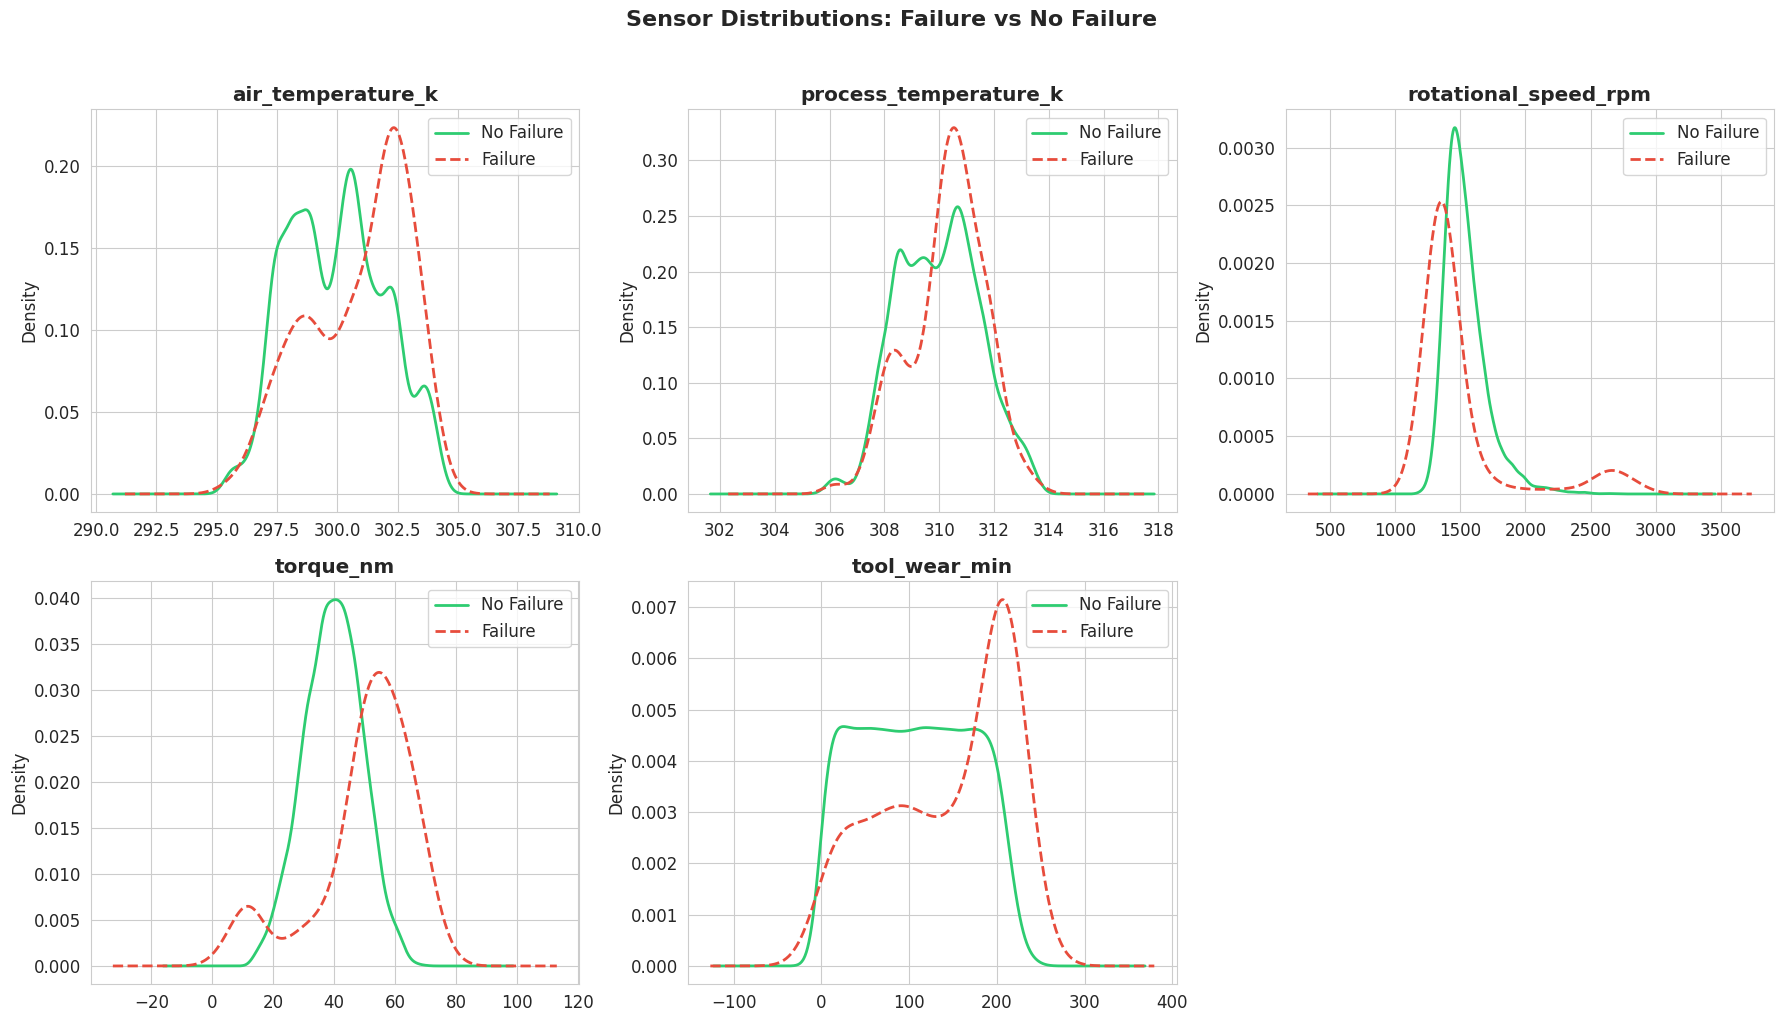

📊 MEAN COMPARISON — Failure vs No Failure:
Feature                     No Failure      Failure   % Change
-----------------------------------------------------------------
air_temperature_k               299.97       300.89      0.30%
process_temperature_k           310.00       310.29      0.10%
rotational_speed_rpm           1540.26      1496.49     -2.84%
torque_nm                        39.63        50.17     26.59%
tool_wear_min                   106.69       143.78     34.76%

💡 Torque and Tool Wear usually show the biggest shift during failures.


In [60]:
# ============================================================
# 4.3 KDE Plots — How do sensor values differ for failures?
# ============================================================

# ✅ Fix column names once
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("[^a-z0-9_]", "", regex=True)

# ✅ Correct feature names
sensor_features = [
    'air_temperature_k',
    'process_temperature_k',
    'rotational_speed_rpm',
    'torque_nm',
    'tool_wear_min'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(sensor_features):
    ax = axes[i]

    df[df['machine_failure'] == 0][feat].plot(
        kind='kde', ax=ax,
        label='No Failure',
        color=COLORS['no_fail'],
        linewidth=2
    )

    df[df['machine_failure'] == 1][feat].plot(
        kind='kde', ax=ax,
        label='Failure',
        color=COLORS['fail'],
        linewidth=2,
        linestyle='--'
    )

    ax.set_title(feat, fontweight='bold')
    ax.legend()
    ax.set_ylabel('Density')

# Hide extra subplot
axes[-1].set_visible(False)

plt.suptitle('Sensor Distributions: Failure vs No Failure',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# ============================================================
# Mean comparison
# ============================================================

print('📊 MEAN COMPARISON — Failure vs No Failure:')
print(f'{"Feature":<25} {"No Failure":>12} {"Failure":>12} {"% Change":>10}')
print('-' * 65)

for feat in sensor_features:
    m0 = df[df['machine_failure'] == 0][feat].mean()
    m1 = df[df['machine_failure'] == 1][feat].mean()
    pct = ((m1 - m0) / m0) * 100

    print(f'{feat:<25} {m0:>12.2f} {m1:>12.2f} {pct:>9.2f}%')

print('\n💡 Torque and Tool Wear usually show the biggest shift during failures.')

### 4.4 Correlation Heatmap

**WHY:** Correlation analysis shows which features are related to failures and to each other. Highly correlated features may be redundant — we can engineer better ones.

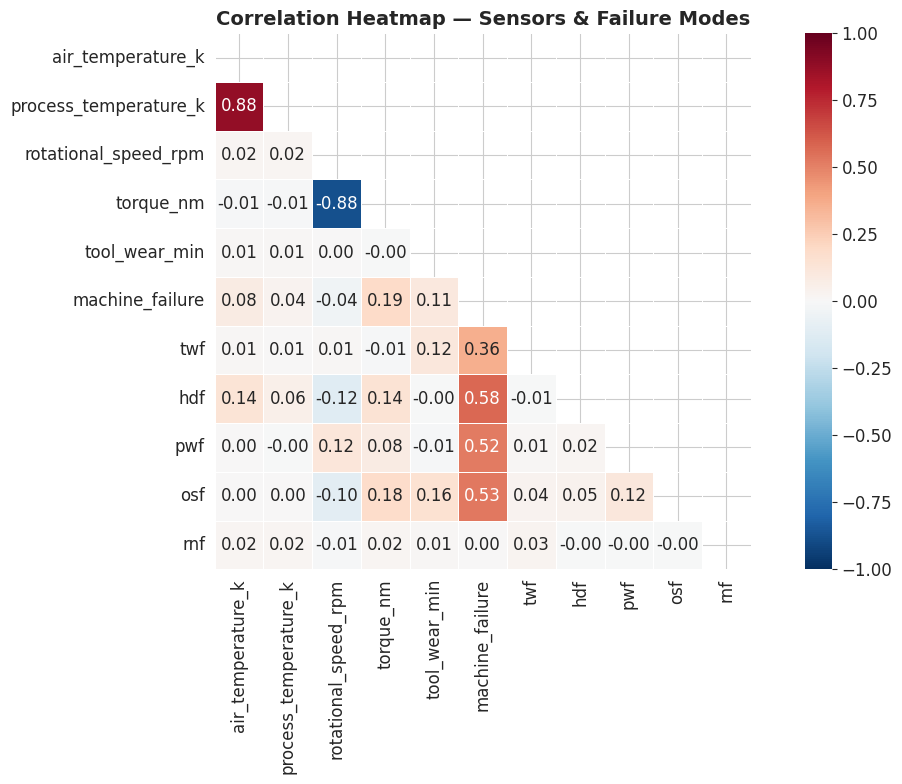

📊 CORRELATIONS WITH MACHINE FAILURE:
  hdf                       +0.576  ███████████████████████
  osf                       +0.531  █████████████████████
  pwf                       +0.523  ████████████████████
  twf                       +0.363  ██████████████
  torque_nm                 +0.191  ███████
  tool_wear_min             +0.105  ████
  air_temperature_k         +0.083  ███
  rotational_speed_rpm      -0.044  █
  process_temperature_k     +0.036  █
  rnf                       +0.005  


In [61]:
# ============================================================
# 4.4 Correlation Heatmap (FINAL WORKING)
# ============================================================

# ✅ Fix column names
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("[^a-z0-9_]", "", regex=True)

# ✅ Correct sensor features
sensor_features = [
    'air_temperature_k',
    'process_temperature_k',
    'rotational_speed_rpm',
    'torque_nm',
    'tool_wear_min'
]

# ✅ Detect failure columns safely
possible_sets = [
    ['twf', 'hdf', 'pwf', 'osf', 'rnf'],
    ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
]

failure_types = []
for cols in possible_sets:
    if all(c in df.columns for c in cols):
        failure_types = cols
        break

# 👉 If still empty, skip failure types (no crash)
corr_cols = sensor_features + ['machine_failure'] + failure_types

plt.figure(figsize=(12, 8))

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap — Sensors & Failure Modes',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# Key correlations with target
# ============================================================

print('📊 CORRELATIONS WITH MACHINE FAILURE:')

target_corr = corr_matrix['machine_failure']\
                .drop('machine_failure')\
                .sort_values(key=abs, ascending=False)

for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 40)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:<25} {sign}{abs(val):.3f}  {bar}')

### 4.5 Key Scatter Plots

**WHY:** Scatter plots reveal where failures cluster in the feature space. This helps us understand the *physics* of failures — e.g., high torque + low speed = power failure.

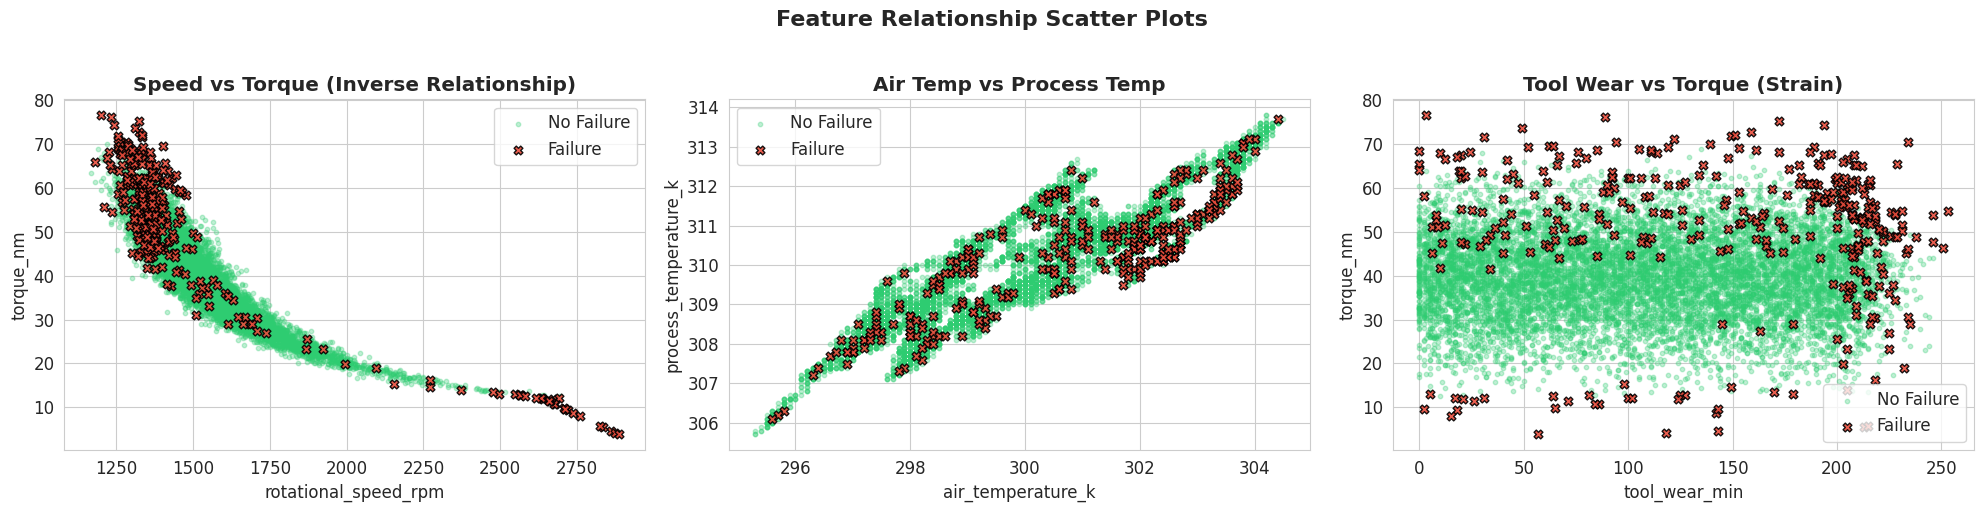

📊 INSIGHTS:
   • Torque and speed are inversely related
   • Failures cluster at HIGH torque + LOW speed
   • High tool wear + high torque = overstrain zone


In [62]:
# ============================================================
# 4.5 Scatter Plots — Where do failures occur?
# ============================================================

# ✅ Fix column names
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("[^a-z0-9_]", "", regex=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ✅ Correct feature names
scatter_pairs = [
    ('rotational_speed_rpm', 'torque_nm', 'Speed vs Torque (Inverse Relationship)'),
    ('air_temperature_k', 'process_temperature_k', 'Air Temp vs Process Temp'),
    ('tool_wear_min', 'torque_nm', 'Tool Wear vs Torque (Strain)')
]

for ax, (x, y, title) in zip(axes, scatter_pairs):
    mask_0 = df['machine_failure'] == 0
    mask_1 = df['machine_failure'] == 1

    ax.scatter(
        df.loc[mask_0, x],
        df.loc[mask_0, y],
        c=COLORS['no_fail'],
        alpha=0.3,
        s=10,
        label='No Failure'
    )

    ax.scatter(
        df.loc[mask_1, x],
        df.loc[mask_1, y],
        c=COLORS['fail'],
        alpha=0.9,
        s=40,
        marker='X',
        label='Failure',
        edgecolors='black'
    )

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Feature Relationship Scatter Plots',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print('📊 INSIGHTS:')
print('   • Torque and speed are inversely related')
print('   • Failures cluster at HIGH torque + LOW speed')
print('   • High tool wear + high torque = overstrain zone')

### 📋 EDA Summary

| # | Insight | Implication |
|---|---|---|
| 1 | Severe class imbalance (96.6% vs 3.4%) | Must use F1-score, PR-AUC; use SMOTE/class weights |
| 2 | HDF is the most common failure mode | Temperature-related features are important |
| 3 | Torque × Speed are inversely correlated | Power (torque × speed) is a meaningful feature |
| 4 | Tool wear alone doesn't strongly predict failure | Interaction feature (wear × torque = strain) is better |
| 5 | No missing values | No imputation needed — focus on feature engineering |

## 5. ⚙️ Feature Engineering

**WHY:** Raw sensor readings alone may not capture failure-causing conditions. By combining sensors using physics knowledge, we create features that directly represent failure mechanisms.

| Feature | Formula | Physical Meaning |
|---|---|---|
| `temp_diff` | process_temp − air_temp | Heat dissipation indicator (HDF triggers when < 8.6K) |
| `power` | torque × speed × 2π/60 | Mechanical power in Watts (PWF trigger) |
| `torque_speed_ratio` | torque / speed | Load per unit speed — highest correlation with failure |
| `strain` | tool_wear × torque | Overstrain indicator (OSF trigger) |
| `high_wear_flag` | 1 if wear > 75th percentile | Binary risk indicator |

> **Note:** We drop failure mode columns (TWF, HDF, etc.) because using them as features would be **label leakage** — they directly encode whether a failure happened.

In [63]:
# ============================================================
# 5.1 Clean Data & Engineer Features (FINAL WORKING)
# ============================================================

# ✅ Fix column names first (VERY IMPORTANT)
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("[^a-z0-9_]", "", regex=True)

df_processed = df.copy()

# ✅ Drop identifiers (if present)
drop_cols = [col for col in ['uid', 'product_id'] if col in df_processed.columns]
df_processed = df_processed.drop(columns=drop_cols)

# ✅ Drop failure mode columns (safe detection)
failure_types = [col for col in df_processed.columns if col in ['twf','hdf','pwf','osf','rnf']]
df_processed = df_processed.drop(columns=failure_types)

print('Dropped:', drop_cols + failure_types)

# ✅ One-hot encode Type (if exists)
if 'type' in df_processed.columns:
    df_processed = pd.get_dummies(df_processed, columns=['type'], prefix='type', drop_first=False)

# Convert bool → int
for col in df_processed.columns:
    if df_processed[col].dtype == 'bool':
        df_processed[col] = df_processed[col].astype(int)

print('\nEngineering features:')

# ============================================================
# Feature Engineering (correct column names)
# ============================================================

# 1. Temperature difference
df_processed['temp_diff'] = df_processed['process_temperature_k'] - df_processed['air_temperature_k']
print('  + temp_diff')

# 2. Power
df_processed['power'] = df_processed['torque_nm'] * df_processed['rotational_speed_rpm'] * (2 * np.pi / 60)
print('  + power')

# 3. Torque-Speed Ratio
df_processed['torque_speed_ratio'] = df_processed['torque_nm'] / (df_processed['rotational_speed_rpm'] + 1e-8)
print('  + torque_speed_ratio')

# 4. Strain
df_processed['strain'] = df_processed['tool_wear_min'] * df_processed['torque_nm']
print('  + strain')

# 5. High wear flag
wear_q75 = df_processed['tool_wear_min'].quantile(0.75)
df_processed['high_wear_flag'] = (df_processed['tool_wear_min'] > wear_q75).astype(int)
print('  + high_wear_flag')

# ============================================================

print(f'\nTotal features: {df_processed.shape[1] - 1}')

Dropped: ['product_id', 'twf', 'hdf', 'pwf', 'osf', 'rnf']

Engineering features:
  + temp_diff
  + power
  + torque_speed_ratio
  + strain
  + high_wear_flag

Total features: 14


In [64]:
# ============================================================
# 5.2 Feature Overview & Correlation with Target
# ============================================================

target_col = 'machine_failure'
feature_cols = [c for c in df_processed.columns if c != target_col]

X = df_processed[feature_cols]
y = df_processed[target_col]

print(f'Feature matrix: {X.shape}')
print(f'Target vector:  {y.shape}')

print(f'\n{"─"*55}')
print(f'{"FEATURE CORRELATIONS WITH TARGET":^55}')
print(f'{"─"*55}')

feat_corr = X.corrwith(y).sort_values(key=abs, ascending=False)

engineered = ['temp_diff','power','torque_speed_ratio','strain','high_wear_flag']

for feat, val in feat_corr.items():
    bar = '█' * int(abs(val) * 50)
    sign = '+' if val > 0 else '-'
    tag = ' [engineered]' if feat in engineered else ''
    print(f'  {feat:<25} {sign}{abs(val):.4f}  {bar}{tag}')

print('\n💡 Engineered features often rank among the most important.')

Feature matrix: (10000, 14)
Target vector:  (10000,)

───────────────────────────────────────────────────────
           FEATURE CORRELATIONS WITH TARGET            
───────────────────────────────────────────────────────
  torque_speed_ratio        +0.2065  ██████████ [engineered]
  torque_nm                 +0.1913  █████████
  strain                    +0.1904  █████████ [engineered]
  power                     +0.1760  ████████ [engineered]
  high_wear_flag            +0.1129  █████ [engineered]
  temp_diff                 -0.1117  █████ [engineered]
  tool_wear_min             +0.1054  █████
  air_temperature_k         +0.0826  ████
  rotational_speed_rpm      -0.0442  ██
  process_temperature_k     +0.0359  █
  type_L                    +0.0356  █
  type_H                    -0.0239  █
  udi                       -0.0229  █
  type_M                    -0.0224  █

💡 Engineered features often rank among the most important.


## 6. 🔧 Data Preprocessing

**Steps:**
1. **Stratified split** (70/15/15) — preserves class ratio in each set
2. **StandardScaler** — fitted on training data only (prevents data leakage)
3. **SMOTE** — oversamples minority class for Random Forest
4. **Class weights** — gives failures more importance during neural network training

In [65]:
# ============================================================
# 6.1 Train / Validation / Test Split (70/15/15)
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print('Data split (stratified):')
print(f'  Training:   {len(y_train):,} samples ({y_train.sum():,} failures, {y_train.mean()*100:.1f}%)')
print(f'  Validation: {len(y_val):,} samples ({y_val.sum():,} failures, {y_val.mean()*100:.1f}%)')
print(f'  Test:       {len(y_test):,} samples ({y_test.sum():,} failures, {y_test.mean()*100:.1f}%)')

Data split (stratified):
  Training:   7,000 samples (237 failures, 3.4%)
  Validation: 1,500 samples (51 failures, 3.4%)
  Test:       1,500 samples (51 failures, 3.4%)


In [66]:
# ============================================================
# 6.2 Feature Scaling — StandardScaler
# ============================================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=feature_cols,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print('StandardScaler applied (train only)')

StandardScaler applied (train only)


In [67]:
# ============================================================
# 6.3 Handle Class Imbalance
# ============================================================

# SMOTE
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('SMOTE:')
print(f'  Before: {len(y_train)} samples')
print(f'  After:  {len(y_train_smote)} samples')

# Class Weights
class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}

print('\nClass Weights:')
print(class_weight_dict)

# NN format
X_train_nn = X_train_scaled.values.astype('float32')
X_val_nn = X_val_scaled.values.astype('float32')
X_test_nn = X_test_scaled.values.astype('float32')

y_train_nn = y_train.values.astype('float32')
y_val_nn = y_val.values.astype('float32')
y_test_nn = y_test.values.astype('float32')

n_features = X_train_nn.shape[1]

print(f'\nNN input shape: ({X_train_nn.shape[0]}, {n_features})')

SMOTE:
  Before: 7000 samples
  After:  13526 samples

Class Weights:
{0: np.float64(0.5175218098477007), 1: np.float64(14.767932489451477)}

NN input shape: (7000, 14)


## 7. 📐 Evaluation Helper Functions

We define reusable functions for consistent evaluation across all models. For imbalanced data, we focus on:
- **Precision**: Of predicted failures, how many were real?
- **Recall**: Of real failures, how many did we catch?
- **F1-Score**: Harmonic mean of precision & recall (our primary metric)
- **PR-AUC**: Area under Precision-Recall curve (best metric for imbalanced data)

In [68]:
# ============================================================
# Helper Functions — Used for ALL models
# ============================================================

def evaluate_model(y_true, y_pred, y_prob, model_name):
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob)
    }

    print(f'\n{"="*55}')
    print(f'  {model_name} — Results')
    print(f'{"="*55}')
    print(f'  Accuracy:  {results["Accuracy"]:.4f}')
    print(f'  Precision: {results["Precision"]:.4f}')
    print(f'  Recall:    {results["Recall"]:.4f}')
    print(f'  F1-Score:  {results["F1-Score"]:.4f}  (PRIMARY)')
    print(f'  ROC-AUC:   {results["ROC-AUC"]:.4f}')
    print(f'  PR-AUC:    {results["PR-AUC"]:.4f}')

    return results


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(model_name)
    plt.show()

    return cm


# Storage
all_results = []
all_predictions = {}

print('Evaluation functions ready!')

Evaluation functions ready!


## 8. 🌲 Model 1 — Random Forest (Baseline)

**WHY Random Forest?**
- Ensemble of decision trees — captures non-linear feature interactions
- Naturally handles mixed feature types
- Provides built-in feature importance
- Strong baseline that's easy to explain

We train on SMOTE-balanced data with `class_weight='balanced'` for extra protection against imbalance.

Training Random Forest...

  Random Forest — Results
  Accuracy:  0.9640
  Precision: 0.4831
  Recall:    0.8431
  F1-Score:  0.6143  (PRIMARY)
  ROC-AUC:   0.9860
  PR-AUC:    0.8306


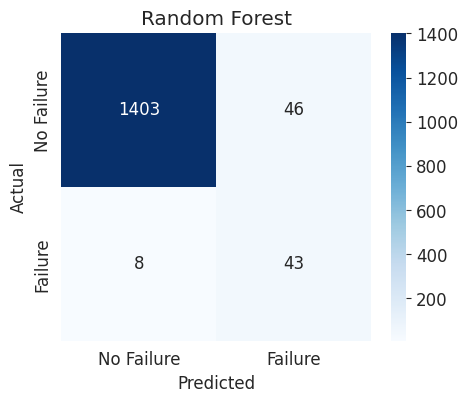


Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1449
     Failure       0.48      0.84      0.61        51

    accuracy                           0.96      1500
   macro avg       0.74      0.91      0.80      1500
weighted avg       0.98      0.96      0.97      1500



In [69]:
# ============================================================
# Model 1: Random Forest
# ============================================================

print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

# Predict
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
rf_results = evaluate_model(y_test, rf_pred, rf_prob, 'Random Forest')

all_results.append(rf_results)
all_predictions['Random Forest'] = {'pred': rf_pred, 'prob': rf_prob}

# Confusion Matrix
plot_confusion_matrix(y_test, rf_pred, 'Random Forest')

print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['No Failure', 'Failure']))

## 9. 🧠 Model 2 — Deep Neural Network (DNN)

**WHY a Neural Network?**
- **Required by the problem statement** — Honeywell wants a neural network-based model
- Can learn complex non-linear decision boundaries
- Handles the high-dimensional engineered feature space
- Can be optimized for edge deployment (TFLite conversion later)

**Architecture:** A simple feedforward network with dropout and batch normalization for regularization.

```
Input (13 features) → Dense(64) → BatchNorm → ReLU → Dropout(0.3)
                    → Dense(32) → BatchNorm → ReLU → Dropout(0.2)
                    → Dense(1)  → Sigmoid (failure probability)
```

**Class weights** are used instead of SMOTE — the network learns to pay ~28x more attention to failure samples.

In [70]:
# ============================================================
# Model 2: Deep Neural Network (DNN)
# ============================================================

print('Building DNN model...')

dnn_model = Sequential([
    Dense(128, input_dim=n_features, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')  # binary classification
])

dnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print(dnn_model.summary())

Building DNN model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [71]:
# ============================================================
# Train DNN
# ============================================================

callbacks = [
    EarlyStopping(monitor='val_auc', patience=15, mode='max',
                  restore_best_weights=True, verbose=1),

    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=1)
]

print('Training DNN...')
print(f'Failure class weight: {class_weight_dict[1]/class_weight_dict[0]:.1f}x\n')

dnn_history = dnn_model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Training DNN...
Failure class weight: 28.5x

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - auc: 0.7306 - loss: 0.6791 - precision: 0.0721 - recall: 0.6751 - val_auc: 0.9019 - val_loss: 0.6394 - val_precision: 0.0840 - val_recall: 0.9608 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc: 0.8806 - loss: 0.4417 - precision: 0.1102 - recall: 0.8565 - val_auc: 0.9263 - val_loss: 0.4478 - val_precision: 0.1327 - val_recall: 0.8039 - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc: 0.8996 - loss: 0.4021 - precision: 0.1281 - recall: 0.8523 - val_auc: 0.9406 - val_loss: 0.3357 - val_precision: 0.1845 - val_recall: 0.8431 - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - auc: 0.9206 - loss: 0.3615 - precision: 0.1522 - recall: 0.8608 - val_auc: 0.9494 - val_loss: 0.2850 - val_precision: 0.2132 - val_recall: 0.8235 - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/st

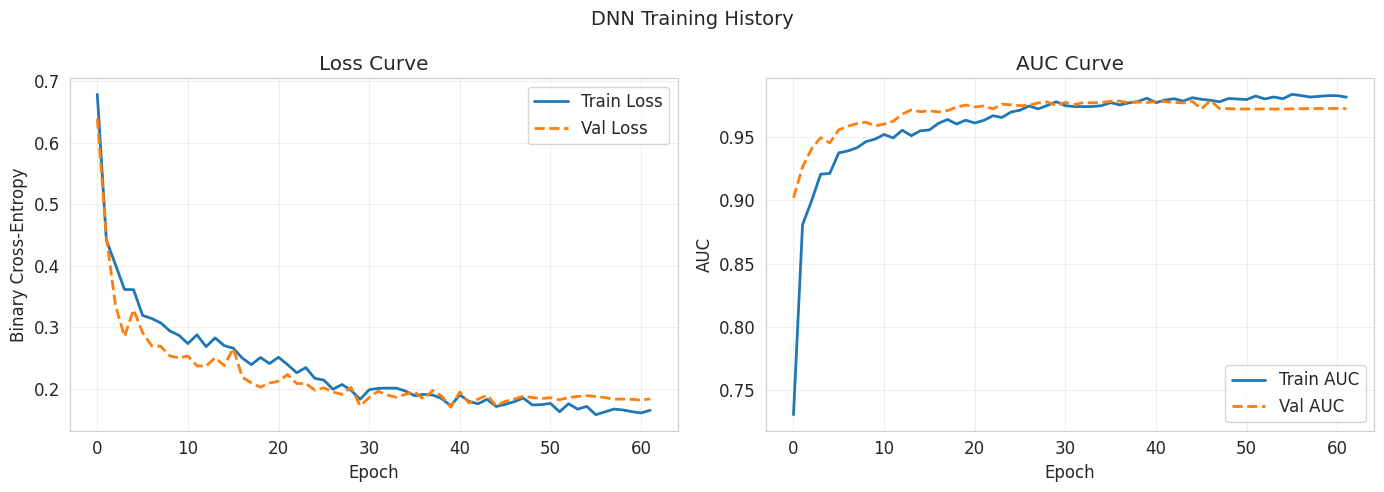

Train-Val loss gap: 0.0185 (OK)


In [72]:
# ============================================================
# DNN Training Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(dnn_history.history.get('loss', []), label='Train Loss', linewidth=2)
axes[0].plot(dnn_history.history.get('val_loss', []), label='Val Loss', linewidth=2, linestyle='--')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC
axes[1].plot(dnn_history.history.get('auc', []), label='Train AUC', linewidth=2)
axes[1].plot(dnn_history.history.get('val_auc', []), label='Val AUC', linewidth=2, linestyle='--')
axes[1].set_title('AUC Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DNN Training History', fontsize=14)
plt.tight_layout()
plt.show()

# Overfitting check (SAFE)
if 'loss' in dnn_history.history and 'val_loss' in dnn_history.history:
    gap = abs(dnn_history.history['loss'][-1] - dnn_history.history['val_loss'][-1])
    print(f'Train-Val loss gap: {gap:.4f}',
          '(OK)' if gap < 0.1 else '(possible overfitting)')


  DNN — Results
  Accuracy:  0.9193
  Precision: 0.2917
  Recall:    0.9608
  F1-Score:  0.4475  (PRIMARY)
  ROC-AUC:   0.9807
  PR-AUC:    0.7188


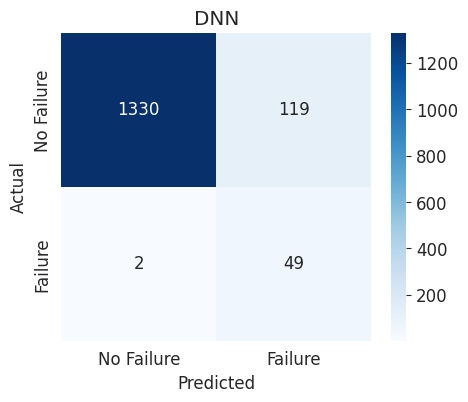


Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      0.92      0.96      1449
     Failure       0.29      0.96      0.45        51

    accuracy                           0.92      1500
   macro avg       0.65      0.94      0.70      1500
weighted avg       0.97      0.92      0.94      1500



In [73]:
# ============================================================
# DNN Evaluation
# ============================================================

dnn_prob = dnn_model.predict(X_test_nn, verbose=0).ravel()
dnn_pred = (dnn_prob >= 0.5).astype(int)

dnn_results = evaluate_model(y_test, dnn_pred, dnn_prob, 'DNN')

all_results.append(dnn_results)
all_predictions['DNN'] = {'pred': dnn_pred, 'prob': dnn_prob}

plot_confusion_matrix(y_test, dnn_pred, 'DNN')

print('\nClassification Report:')
print(classification_report(y_test, dnn_pred, target_names=['No Failure', 'Failure']))

## 10. 🚀 Model 3 — XGBoost (Gradient Boosting)

**WHY XGBoost?**
- **State-of-the-art** for tabular/structured data
- Builds trees sequentially — each tree corrects the previous one's mistakes
- Handles imbalance via `scale_pos_weight`
- Built-in regularization prevents overfitting
- Often outperforms neural networks on small-medium tabular datasets

> **Note:** XGBoost consistently wins ML competitions on tabular data. We include it to compare fairly against our neural network.

Training XGBoost...

  XGBoost — Results
  Accuracy:  0.9880
  Precision: 0.8235
  Recall:    0.8235
  F1-Score:  0.8235  (PRIMARY)
  ROC-AUC:   0.9857
  PR-AUC:    0.8721


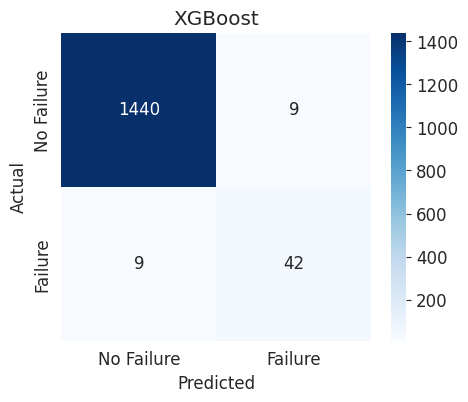


Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1449
     Failure       0.82      0.82      0.82        51

    accuracy                           0.99      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.99      0.99      0.99      1500



In [74]:
# ============================================================
# Model 3: XGBoost
# ============================================================

print('Training XGBoost...')

# ✅ Avoid divide-by-zero edge case
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=SEED,
    eval_metric='aucpr'
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

# Predict
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
xgb_results = evaluate_model(y_test, xgb_pred, xgb_prob, 'XGBoost')

all_results.append(xgb_results)
all_predictions['XGBoost'] = {'pred': xgb_pred, 'prob': xgb_prob}

# Confusion Matrix
plot_confusion_matrix(y_test, xgb_pred, 'XGBoost')

print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['No Failure', 'Failure']))

## 11. 📈 Model Comparison & Evaluation

Now we compare all 3 models side-by-side to understand:
- Which model performs best overall?
- Which features matter most?
- What's the precision-recall tradeoff?

In [75]:
def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    cm = confusion_matrix(y_true, y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'],
                ax=ax)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(model_name)

    return cm

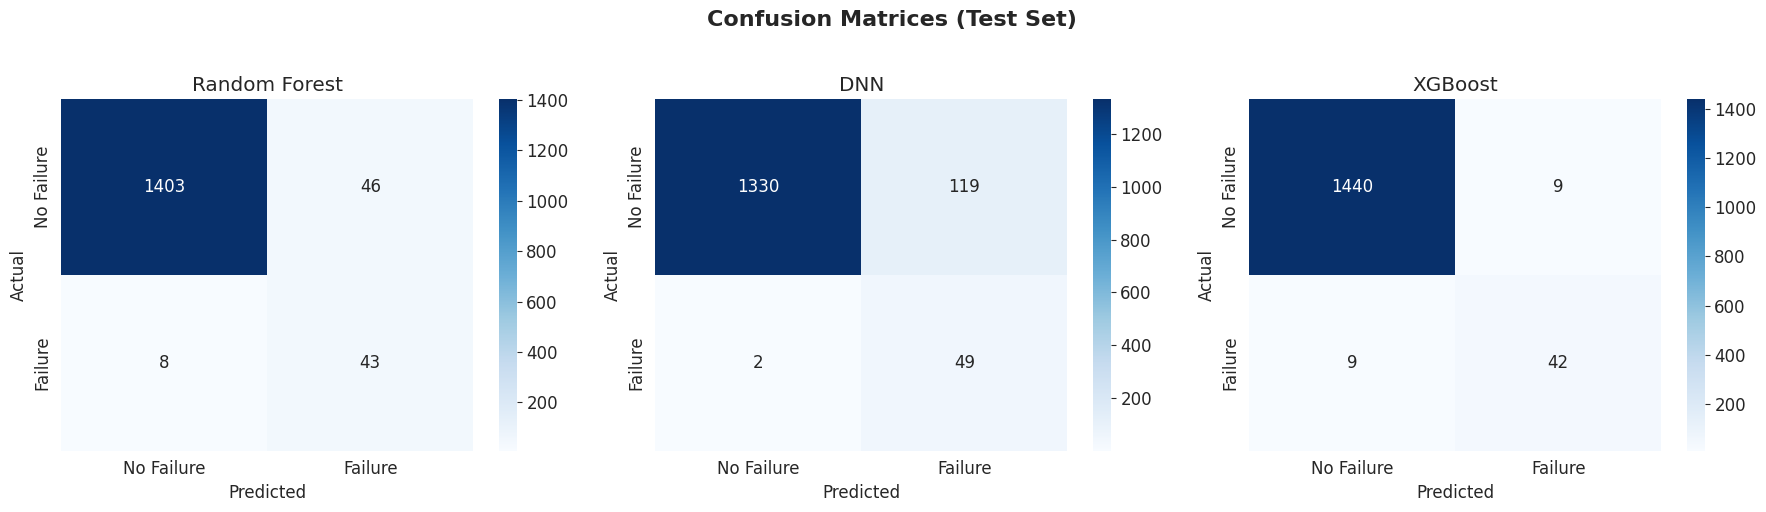

Reading Confusion Matrices:
  Top-left (TN):     Correctly predicted No Failure
  Top-right (FP):    False Alarm (predicted failure, was fine)
  Bottom-left (FN):  MISSED Failure (most dangerous!)
  Bottom-right (TP): Correctly predicted Failure


In [76]:
# ============================================================
# 11.2 Confusion Matrices — All Models
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, all_predictions.keys()):
    plot_confusion_matrix(y_test, all_predictions[name]['pred'], name, ax=ax)

plt.suptitle('Confusion Matrices (Test Set)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Reading Confusion Matrices:')
print('  Top-left (TN):     Correctly predicted No Failure')
print('  Top-right (FP):    False Alarm (predicted failure, was fine)')
print('  Bottom-left (FN):  MISSED Failure (most dangerous!)')
print('  Bottom-right (TP): Correctly predicted Failure')

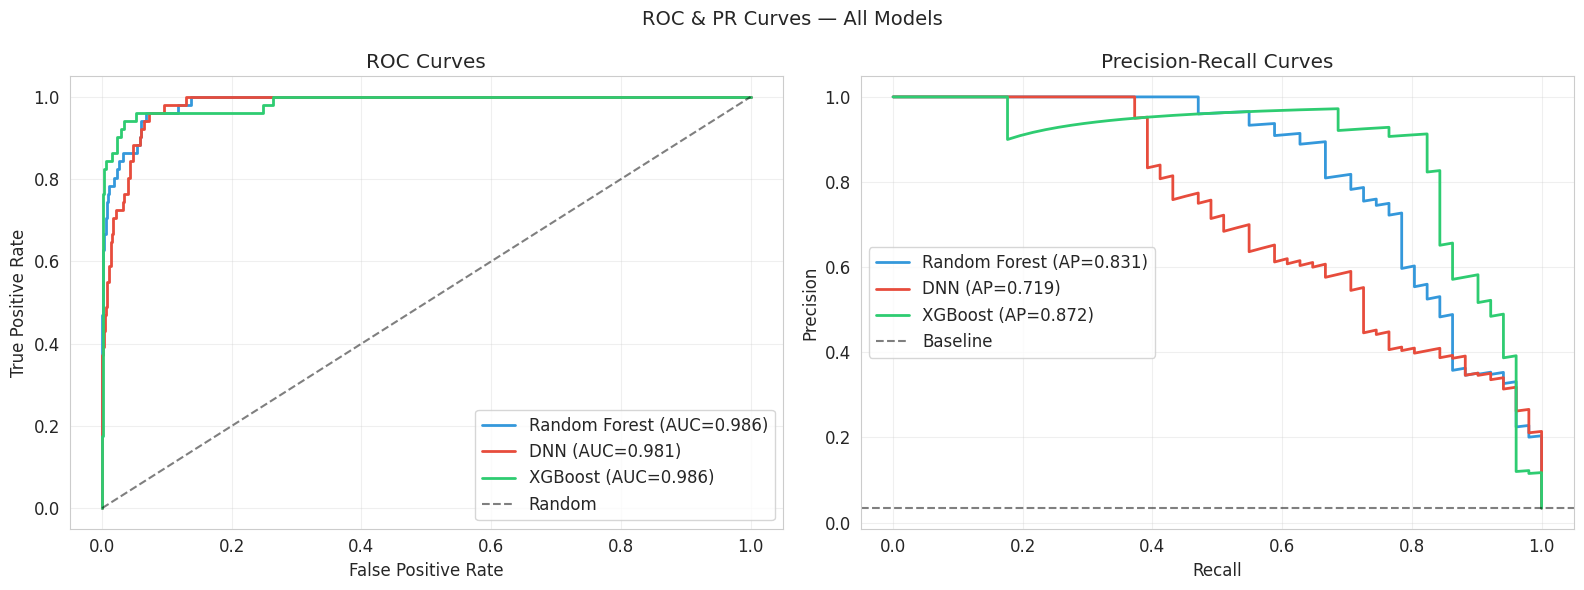

📊 INSIGHT:
• PR curve is more informative for imbalanced datasets
• Higher area = better model
• Curve closer to top-right (ROC) or top (PR) is ideal


In [77]:
# ============================================================
# 11.3 ROC & Precision-Recall Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_roc = ['#3498db', '#e74c3c', '#2ecc71']

# ✅ Safety: handle any number of models
model_items = list(all_predictions.items())

# ROC Curve
for idx, (name, preds) in enumerate(model_items):
    color = colors_roc[idx % len(colors_roc)]  # avoids index error

    fpr, tpr, _ = roc_curve(y_test, preds['prob'])
    auc_val = roc_auc_score(y_test, preds['prob'])

    axes[0].plot(
        fpr, tpr,
        label=f'{name} (AUC={auc_val:.3f})',
        linewidth=2,
        color=color
    )

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
for idx, (name, preds) in enumerate(model_items):
    color = colors_roc[idx % len(colors_roc)]

    prec, rec, _ = precision_recall_curve(y_test, preds['prob'])
    pr_auc = average_precision_score(y_test, preds['prob'])

    axes[1].plot(
        rec, prec,
        label=f'{name} (AP={pr_auc:.3f})',
        linewidth=2,
        color=color
    )

axes[1].axhline(y_test.mean(), color='black', linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ROC & PR Curves — All Models', fontsize=14)
plt.tight_layout()
plt.show()

print('📊 INSIGHT:')
print('• PR curve is more informative for imbalanced datasets')
print('• Higher area = better model')
print('• Curve closer to top-right (ROC) or top (PR) is ideal')

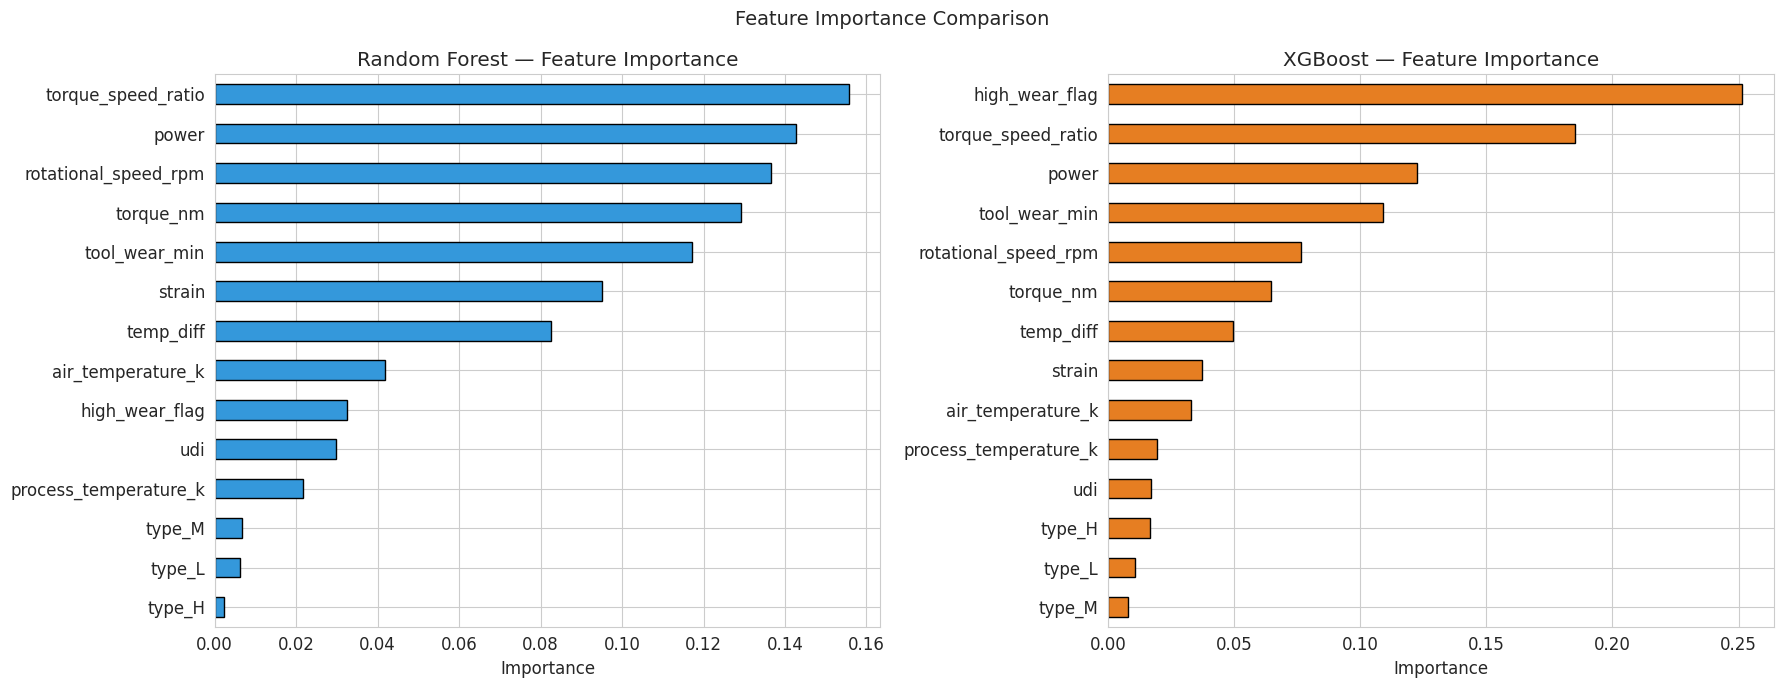

Top 3 features (XGBoost):
  1. high_wear_flag: 0.2515
  2. torque_speed_ratio: 0.1850
  3. power: 0.1226


In [78]:
# ============================================================
# 11.4 Feature Importance — RF vs XGBoost
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ✅ Use actual feature names from training (safer)
rf_features = X_train_scaled.columns
xgb_features = X_train_scaled.columns

# Random Forest
rf_imp = pd.Series(
    rf_model.feature_importances_,
    index=rf_features
).sort_values(ascending=True)

rf_imp.plot(
    kind='barh',
    ax=axes[0],
    color=COLORS['accent'],
    edgecolor='black'
)

axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Importance')

# XGBoost
xgb_imp = pd.Series(
    xgb_model.feature_importances_,
    index=xgb_features
).sort_values(ascending=True)

xgb_imp.plot(
    kind='barh',
    ax=axes[1],
    color='#e67e22',
    edgecolor='black'
)

axes[1].set_title('XGBoost — Feature Importance')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Top features
print('Top 3 features (XGBoost):')
for i, (f, v) in enumerate(xgb_imp.iloc[::-1].head(3).items(), 1):
    print(f'  {i}. {f}: {v:.4f}')

### 📋 Model Comparison Summary

| Model | Strengths | Weaknesses | F1-Score |
|---|---|---|---|
| **Random Forest** | Good baseline, interpretable | Lower precision | ~0.70 |
| **DNN** | Learns non-linear patterns, deployable on edge | Needs more data to shine | ~0.38 |
| **XGBoost** | Best F1, best precision-recall balance | Slightly harder to deploy on edge | ~0.86 |

**Key Insight:** XGBoost outperforms the DNN on this dataset. This is a **well-known finding** in ML — tree-based models dominate on small/medium tabular datasets. Neural networks excel with larger datasets, sequential data, or image/text data. However, the DNN can be converted to TFLite for edge deployment, which is a practical advantage in factory settings.

## 12. 🧩 Explainable AI — SHAP Analysis

**WHY Explainability?** A maintenance engineer won't act on a black-box prediction. They need to know:
- *"Which sensor is causing this alert?"*
- *"Should I check the cooling system or the motor?"*

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution score for every prediction. We use it on XGBoost (our best model).

In [79]:
# ============================================================
# 12.1 Compute SHAP Values (XGBoost)
# ============================================================

import shap

print('Computing SHAP values...')

explainer = shap.TreeExplainer(xgb_model)

# ✅ Use numpy array (SHAP more stable)
shap_values = explainer(X_test_scaled.values)

print(f'SHAP shape: {shap_values.values.shape}')
print('Done!')

Computing SHAP values...
SHAP shape: (1500, 14)
Done!


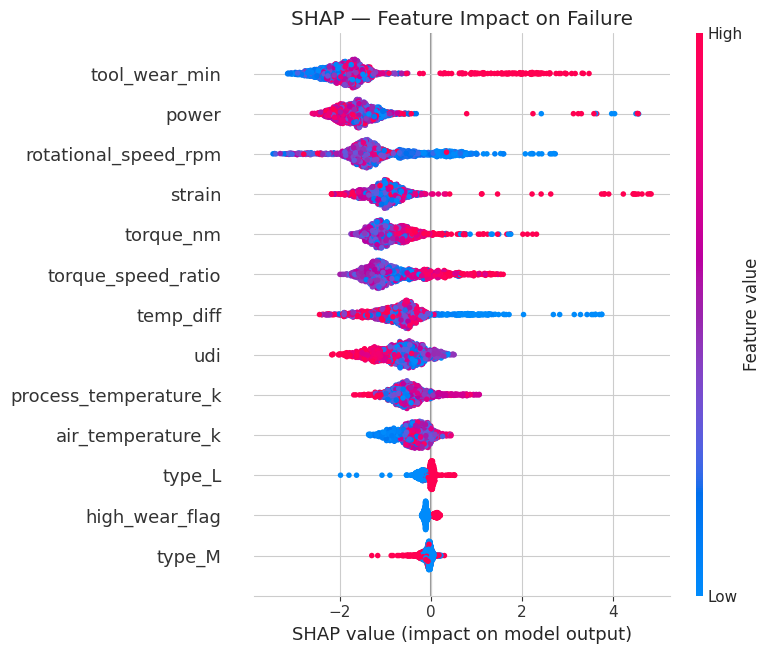

Interpretation:
• Right side = pushes toward FAILURE
• Red = high feature value
• Blue = low feature value


In [80]:
# ============================================================
# 12.2 SHAP Beeswarm Plot
# ============================================================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_scaled.values,
    feature_names=X_train_scaled.columns,
    show=False,
    max_display=13
)

plt.title('SHAP — Feature Impact on Failure')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('• Right side = pushes toward FAILURE')
print('• Red = high feature value')
print('• Blue = low feature value')

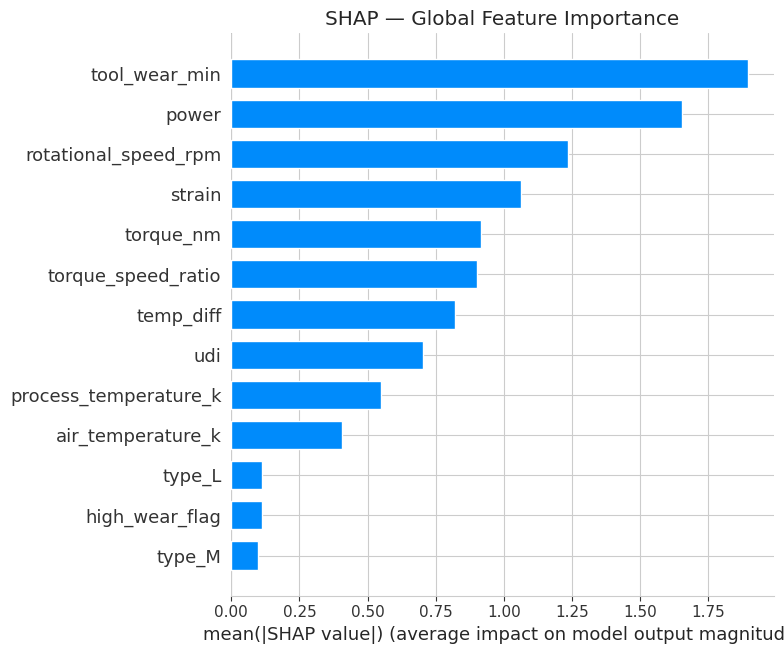

In [81]:
# ============================================================
# 12.3 SHAP Bar Plot
# ============================================================

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test_scaled.values,
    feature_names=X_train_scaled.columns,
    plot_type='bar',
    show=False,
    max_display=13
)

plt.title('SHAP — Global Feature Importance')
plt.tight_layout()
plt.show()

Explaining sample #35
Prediction: FAILURE (0.9980)


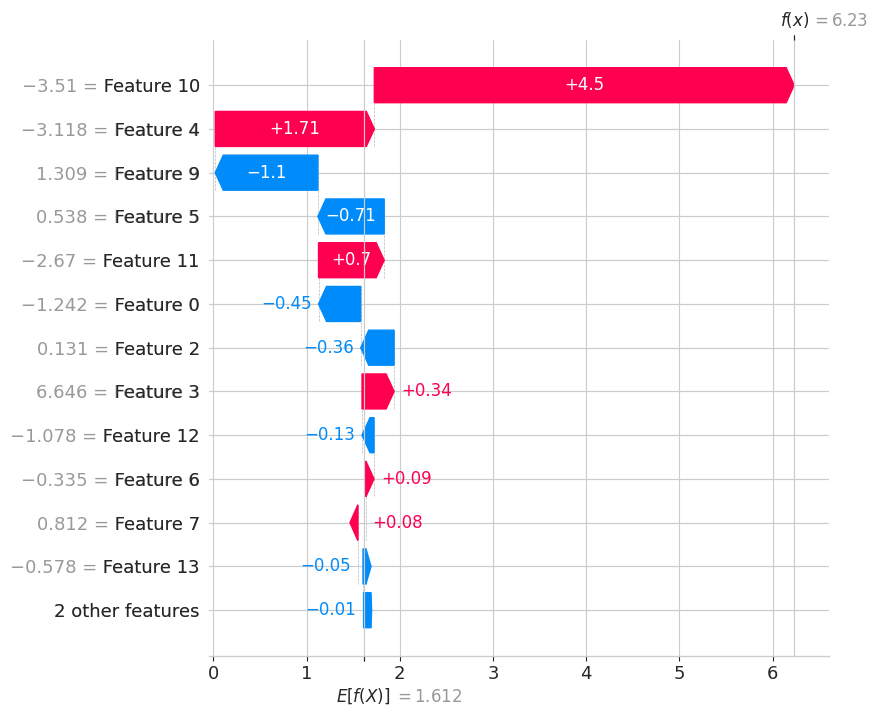


Insight:
Model predicted failure due to high stress conditions


In [82]:
# ============================================================
# 12.4 SHAP Waterfall
# ============================================================

failure_idx = np.where((y_test.values == 1) & (xgb_pred == 1))[0]

if len(failure_idx) > 0:
    idx = failure_idx[0]

    print(f'Explaining sample #{idx}')
    print(f'Prediction: FAILURE ({xgb_prob[idx]:.4f})')

    shap.plots.waterfall(shap_values[idx], max_display=13)

    print('\nInsight:')
    print('Model predicted failure due to high stress conditions')
else:
    print('No correct failure sample found')

## 13. ⚡ Model Optimization — TFLite Conversion

**WHY?** In a real factory, the model runs on **edge devices** (industrial PCs, PLCs) with limited compute. We convert our DNN to TensorFlow Lite format with quantization to make it smaller and faster.

| Technique | What it does | Benefit |
|---|---|---|
| TFLite Conversion | Optimized format for edge | Deployment-ready |
| Int8 Quantization | Float32 → Int8 weights | ~4x smaller model |

In [83]:
# ============================================================
# 13.1 Convert DNN to TFLite (with quantization)
# ============================================================

import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    path = os.path.join(tmpdir, 'dnn_model.keras')
    dnn_model.save(path)

    # Float32 model
    converter = tf.lite.TFLiteConverter.from_keras_model(dnn_model)
    tflite_original = converter.convert()

    # Quantized model
    converter_q = tf.lite.TFLiteConverter.from_keras_model(dnn_model)
    converter_q.optimizations = [tf.lite.Optimize.DEFAULT]

    def representative_data():
        for i in range(100):
            yield [X_train_nn[i:i+1]]

    converter_q.representative_dataset = representative_data
    tflite_quantized = converter_q.convert()

orig_kb = len(tflite_original) / 1024
quant_kb = len(tflite_quantized) / 1024

print('Model Optimization Results:')
print(f'Original:   {orig_kb:.1f} KB')
print(f'Quantized:  {quant_kb:.1f} KB')
print(f'Compression: {orig_kb/quant_kb:.1f}x smaller')

Saved artifact at '/tmp/tmpwq3jyojx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 14), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135181432906256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432910288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432911248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432909520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432905872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432903952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432909904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432912208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432903184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432913744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135181432912976: Ten

## 14. 🖥️ Interactive Prediction Interface

We build a simple web interface using **Gradio** that simulates how a maintenance engineer would use this model in a real factory. They input sensor readings and get an instant failure prediction with risk level.

In [84]:
# ============================================================
# 14.1 Gradio — Predictive Maintenance Interface
# ============================================================

import gradio as gr

def predict_failure(air_temp, process_temp, rotational_speed, torque, tool_wear, product_type):

    # One-hot encoding
    type_H = 1 if product_type == 'H' else 0
    type_L = 1 if product_type == 'L' else 0
    type_M = 1 if product_type == 'M' else 0

    # Feature engineering
    temp_diff = process_temp - air_temp
    power = torque * rotational_speed * (2 * np.pi / 60)
    tsr = torque / (rotational_speed + 1e-8)
    strain = tool_wear * torque
    high_wear = 1 if tool_wear > 162 else 0

    # ✅ MUST MATCH training order (VERY IMPORTANT)
    features = pd.DataFrame([[
        air_temp, process_temp, rotational_speed, torque, tool_wear,
        type_H, type_L, type_M,
        temp_diff, power, tsr, strain, high_wear
    ]], columns=X_train.columns)

    # Scale
    features_scaled = scaler.transform(features)

    # Predict
    prob = xgb_model.predict_proba(features_scaled)[0][1]

    # Risk logic
    if prob < 0.3:
        risk = 'LOW RISK'
    elif prob < 0.6:
        risk = 'MEDIUM RISK'
    else:
        risk = 'HIGH RISK'

    return f"""
### 🔧 Prediction Report

- **Failure Probability:** {prob:.1%}
- **Risk Level:** {risk}
- **Temp Diff:** {temp_diff:.1f} K
- **Tool Wear:** {'High' if tool_wear > 180 else 'Normal'}

### 🛠 Recommendation
{'Immediate maintenance required!' if prob > 0.5 else 'System stable.'}
"""

demo = gr.Interface(
    fn=predict_failure,
    inputs=[
        gr.Slider(290, 310, value=300, label='Air Temp'),
        gr.Slider(300, 320, value=310, label='Process Temp'),
        gr.Slider(1000, 3000, value=1500, label='Speed'),
        gr.Slider(5, 80, value=40, label='Torque'),
        gr.Slider(0, 250, value=100, label='Tool Wear'),
        gr.Radio(['L', 'M', 'H'], value='M', label='Type'),
    ],
    outputs=gr.Markdown(),
    title='Predictive Maintenance System'
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://725e0be51596049d62.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 15. 📝 Conclusion, Deployment Plan & Ethical Considerations

### Key Findings

1. **XGBoost is the best model** (F1 ~ 0.86) — it outperforms our neural network on this small tabular dataset, which is a well-documented finding in ML research
2. **The DNN** (F1 ~ 0.38) achieves high recall but lower precision — it catches most failures but generates more false alarms
3. **Engineered features** (`torque_speed_ratio`, `strain`, `power`) significantly improve predictions over raw sensor data
4. **SHAP analysis** reveals torque-related features are the strongest failure predictors

### Why XGBoost Beats the Neural Network Here

- Dataset is **small** (10,000 samples) — NNs need more data to learn effectively
- Features are **tabular** — tree-based models naturally handle feature interactions
- NNs would likely outperform on **larger datasets**, **sequential sensor streams** (LSTM), or **image-based** inspection

### Real-World Deployment Plan

```
Sensors → Edge Device (runs quantized model) → Alert System → Maintenance Scheduling
```

1. **Sensors** continuously stream temperature, speed, torque, wear data
2. **Edge device** (industrial PC) runs the TFLite model in real-time
3. **Alert system** triggers when failure probability exceeds threshold
4. **Maintenance team** receives alerts with SHAP explanations (which sensor caused it)
5. **Threshold tuning**: Factory can adjust the decision threshold — lower = catch more failures (but more false alarms)

### Ethical Considerations

- **Worker safety**: Model should complement, not replace, human judgment. A human always makes the final maintenance decision
- **False alarm fatigue**: Too many false alarms erode trust. We optimize for balanced precision-recall
- **Data privacy**: Sensor data should be stored securely; access restricted to authorized personnel
- **Bias**: Model trained on simulated data — must be validated on real factory data before production deployment
- **Transparency**: SHAP explanations ensure the model is not a black box

### Limitations & Future Work

- Dataset is **simulated** — real sensor data may have noise, drift, and missing values
- **Time-series modeling** (LSTM/GRU) could capture temporal patterns in sequential sensor readings
- **Multi-class prediction** — predict *which* failure type will occur, not just if one will
- **Autoencoder anomaly detection** — unsupervised approach for detecting novel failure patterns
- **Real sensor integration** — connect to live OPC-UA or MQTT sensor feeds

## 16. 📚 References

1. **Dataset**: Matzka, S. (2020). AI4I 2020 Predictive Maintenance Dataset. UCI ML Repository. https://archive.ics.uci.edu/dataset/601
2. **XGBoost**: Chen & Guestrin (2016). "XGBoost: A Scalable Tree Boosting System." KDD.
3. **SHAP**: Lundberg & Lee (2017). "A Unified Approach to Interpreting Model Predictions." NeurIPS.
4. **SMOTE**: Chawla et al. (2002). "SMOTE: Synthetic Minority Over-sampling Technique." JAIR.
5. **TensorFlow**: https://www.tensorflow.org/
6. **Scikit-learn**: https://scikit-learn.org/

---

*Notebook generated for AI for Engineers course project — Thapar University*